In [2]:
from dopplerguesser.misc.curve_generator import generate_doppler_curve
from dopplerguesser.predict.observer import Observer
from dopplerguesser.predict.satellite import Satellite
import time
from matplotlib import pyplot as plt

In [3]:
ts = time.time()
TLE = """ELEKTRO-L 2             
1 41105U 15074A   26123.12218855 -.00000110  00000+0  00000+0 0  9995
2 41105   6.5831  71.0674 0002015 272.1658 267.2595  1.00271223 38050"""

In [4]:
obs = Observer(55, 37, 200)
sat = Satellite(*TLE.splitlines(), ts)

In [5]:
dopplerdata = generate_doppler_curve(sat, obs, 3.5e9, ts, 86400, 60, simulated_noise=0)

In [6]:
dopplerdata[0:10]

[(np.int64(0), np.float64(3500000308.976146)),
 (np.int64(60), np.float64(3500000310.767996)),
 (np.int64(120), np.float64(3500000312.5530477)),
 (np.int64(180), np.float64(3500000314.331274)),
 (np.int64(240), np.float64(3500000316.102647)),
 (np.int64(300), np.float64(3500000317.867137)),
 (np.int64(360), np.float64(3500000319.624717)),
 (np.int64(420), np.float64(3500000321.3753595)),
 (np.int64(480), np.float64(3500000323.1190376)),
 (np.int64(540), np.float64(3500000324.8557224))]

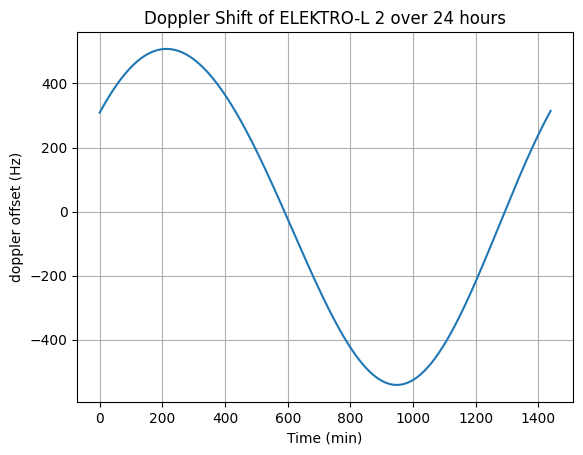

In [8]:

xvalues, yvalues = zip(*dopplerdata)
yvalues = [y - 3.5e9 for y in yvalues]
xvalues = [x / 60 for x in xvalues]
plt.plot(xvalues, yvalues)
plt.xlabel("Time (min)")
plt.ylabel("doppler offset (Hz)")
plt.title(f"Doppler Shift of {sat.name.strip()} over 24 hours")
plt.grid()
plt.show()

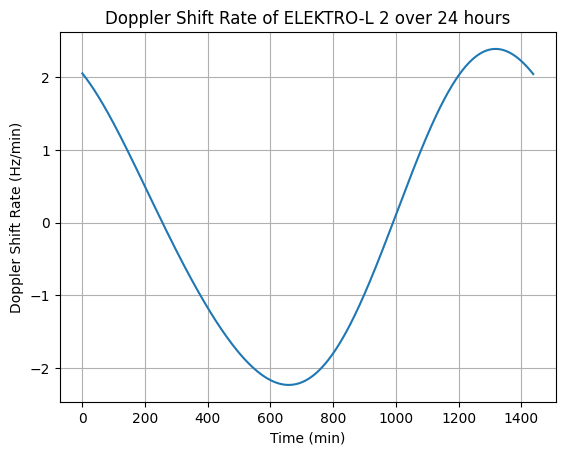

In [ ]:
derivative = [(yvalues[i+1] - yvalues[i]) / (xvalues[i+1] - xvalues[i]) for i in range(len(yvalues)-1)]
plt.plot(xvalues[:-1], derivative)
plt.xlabel("Time (min)")
plt.ylabel("Doppler Shift Rate (Hz/min)")
plt.grid()
plt.show()